In [13]:
from dataclasses import dataclass
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

from profiles import InfectiousnessToTransmission

In [71]:
@dataclass(frozen=True)
class Hypothesis:
    """
    Transmission history hypothesis.

    AD(m):
        i is ancestral to j with m hidden intermediates between them.

    CA(mi, mj):
        i and j descend from a shared unsampled common ancestor with
        mi intermediates on the path to i and mj on the path to j.
    """
    kind: str
    m: int = None
    mi: int = None
    mj: int = None

    def label(self) -> str:
        if self.kind == "AD":
            return f"HAD({self.m})"
        return f"HCA({self.mi},{self.mj})"

class EpiLink:
    """
    Pairwise epilink posterior inference.

    Parameters
    ----------
    transmission_profile :
        Instance of InfectiousnessToTransmission providing latent-time samples and
         branch-specific per-day rates.
    maximum_depth :
        Maximum hidden-depth parameter.
    mc_samples :
        Number of Monte Carlo samples per hypothesis.
    """

    def __init__(self,
                 transmission_profile: InfectiousnessToTransmission,
                 maximum_depth: int = 2,
                 mc_samples: int = 10000,
                 rng: np.random.Generator = None) -> None:
        if maximum_depth < 0:
            raise ValueError("maximum_depth must be >= 0.")

        self.profile = transmission_profile
        self.mc_samples = int(mc_samples)
        self.M = int(maximum_depth)
        self.hypotheses = self._enumerate_hypotheses()

    def _enumerate_hypotheses(self) -> list[Hypothesis]:
        hypotheses: list[Hypothesis] = []

        for m in range(self.M + 1):
            hypotheses.append(Hypothesis(kind="AD", m=m))

        for mi in range(self.M + 1):
            for mj in range(self.M + 1 - mi):
                hypotheses.append(Hypothesis(kind="CA", mi=mi, mj=mj))

        return hypotheses

        self.hypotheses = self.prior.hypotheses

    def simulate_hypotheses(
        self,
        hypothesis: Hypothesis,
        n: int = None,
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        Simulate T_ij(H) and B_H.

        Returns
        -------
        T_draws : ndarray, shape (n,)
            Simulated sample-date differences under H.
        B_draws : ndarray, shape (n,)
            Simulated total branch lengths in days under H.
        """
        n = self.mc_samples if n is None else int(n)

        incubation_i = self.profile.sample_incubation_periods(n)
        incubation_j = self.profile.sample_incubation_periods(n)
        delay_i = self.profile.sample_testing_delays(n)
        delay_j = self.profile.sample_testing_delays(n)

        if hypothesis.kind == "AD":
            m = int(hypothesis.m)
            generations = np.zeros(n, dtype=float)
            for _ in range(m + 1):
                generations += self.profile.sample_generation_intervals(n)

            # Temporal part: sample-date difference
            T = generations + incubation_j + delay_j - incubation_i - delay_i

            # Genetic part: branch length between genomes
            # For AD, this is the elapsed path from i sampling lineage to j sampling lineage.
            B = generations + incubation_j + delay_j - (incubation_i + delay_i)

        elif hypothesis.kind == "CA":
            mi = int(hypothesis.mi)
            mj = int(hypothesis.mj)

            path_i = np.zeros(n, dtype=float)
            path_j = np.zeros(n, dtype=float)

            for _ in range(mi + 1):
                path_i += self.profile.sample_generation_intervals(n)
            for _ in range(mj + 1):
                path_j += self.profile.sample_generation_intervals(n)

            T = path_j - path_i + incubation_j + delay_j - incubation_i - delay_i

            B = path_i + path_j + incubation_i + delay_i + incubation_j + delay_j

        else:
            raise ValueError(f"Unknown hypothesis kind: {hypothesis.kind}")

        return T, np.clip(B, a_min=0.0, a_max=np.inf)

    @staticmethod
    def percentile_score(observed, expected):
        expected = np.asarray(expected)
        return np.mean(expected <= observed)

    def compatibility_score(self, observed, expected, genetic: bool=False):
        if genetic:
            rates = self.profile.sample_clock_rate(size=expected.shape)
            expected = expected * rates
            # expected = stats.poisson.rvs(rates * expected)
        p = self.percentile_score(observed, expected)
        return 1 - 2 * abs(p - 0.5)

    def score_pair(
        self,
        t_ij,
        g_ij,
    ) -> dict[str, object]:
        """
        Compute posterior over all hypotheses for one pair.

        Returns
        -------
        dict with keys:
            posterior
            weights
            components
            epilink_score
        """
        weights: dict[str, float] = {}
        components: dict[str, dict[str, float]] = {}

        for h in self.hypotheses:
            T_draws, B_draws = self.simulate_hypotheses(h, n=self.mc_samples)

            LT = self.compatibility_score(observed=t_ij, expected=T_draws)
            LG = self.compatibility_score(observed=g_ij, expected=B_draws, genetic=True)

            weight = LT * LG
            label = h.label()

            weights[label] = weight
            components[label] = {
                "LT": LT,
                "LG": LG,
            }

        total = sum(weights.values())
        if total <= 0:
            posterior = {k: 0 for k, v in weights.items()}
        else:
            posterior = {k: v / total for k, v in weights.items()}

        epilink_score = posterior.get("HAD(0)", 0.0) + posterior.get("HCA(0,0)", 0.0)

        return {
            "posterior": posterior,
            "weights": weights,
            "components": components,
            "epilink_score": epilink_score,
        }

In [72]:
epilink = EpiLink(transmission_profile=toit, maximum_depth=2, mc_samples=10000)

In [73]:
g = np.arange(20)
score = []
for g_ij in genetic:
    result = epilink.score_pair(t_ij=0, g_ij=g_ij)
    score.append(result["epilink_score"])

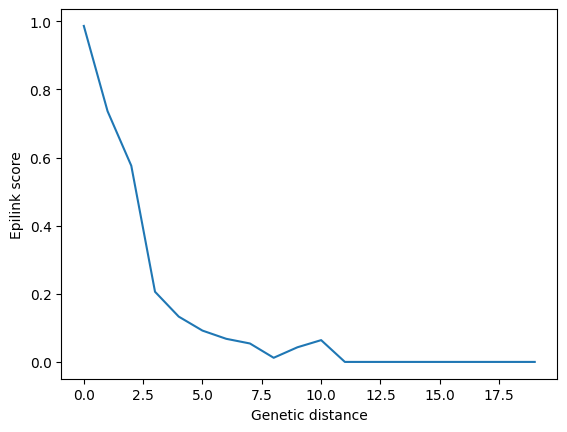

In [74]:
plt.plot(g, score)
plt.xlabel("Genetic distance")
plt.ylabel("Epilink score")
plt.show()